In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def dX(drift : float, sigma : float = 1, mul1 : float = 1 , mul2 : float = 1): #brownian motion simulation dX
    n = 10000
    T = 20
    d = 15

    times = np.linspace(0., T, n)
    dt = times[1] - times[0]

    W0 = np.zeros(shape = (1, d))

    dW = np.random.normal(
        size = (n - 1, d),
        loc = drift * dt * mul1,
        scale = np.sqrt(dt) * sigma * mul2
    )

    W_t = np.concatenate(
        (W0, np.cumsum(dW, axis = 0)),
        axis = 0
    )

    QV_W = np.cumsum(
        np.power(np.diff(W_t, axis = 0), 2),
        axis = 0
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

    ax1.plot(times, W_t)

    M = np.max(np.abs(W_t))
    ax1.set_ylim(-M, M)

    ax1.set_title(
        f"drift = {drift:.2f}, sigma = {sigma:.2f}, "
        f"multiplier1 = {mul1:.2f}, multiplier2 = {mul2:.2f}"
    )

    ax2.plot(times[1:], QV_W)

    ax2.plot(
        times[1:],
        (sigma * mul2) ** 2 * times[1:],
        '-',
        linewidth = 6,
        c = "black",
        alpha = 0.6
    )

    ax2.set_xlim(0, 2.5)
    ax2.set_title("Quadratic Variation")

    plt.tight_layout()
    plt.show()

# Model 1: $dS = \mu dt + \sigma dX$ 

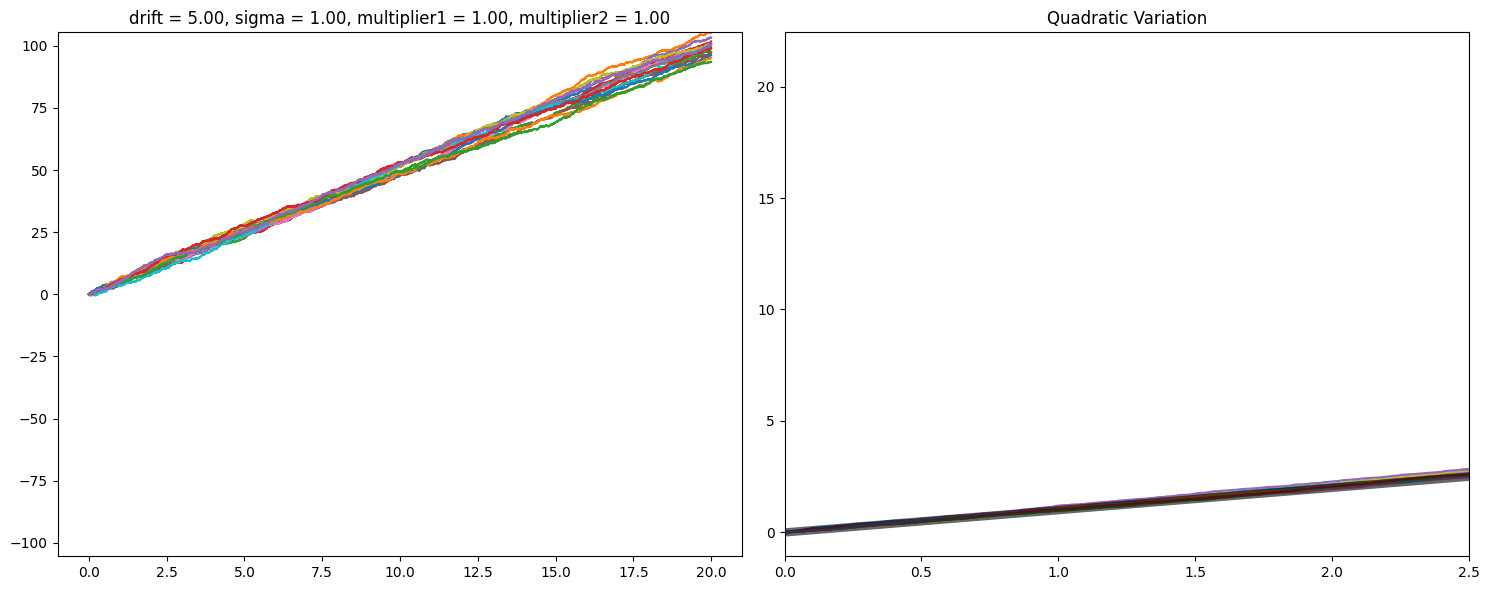

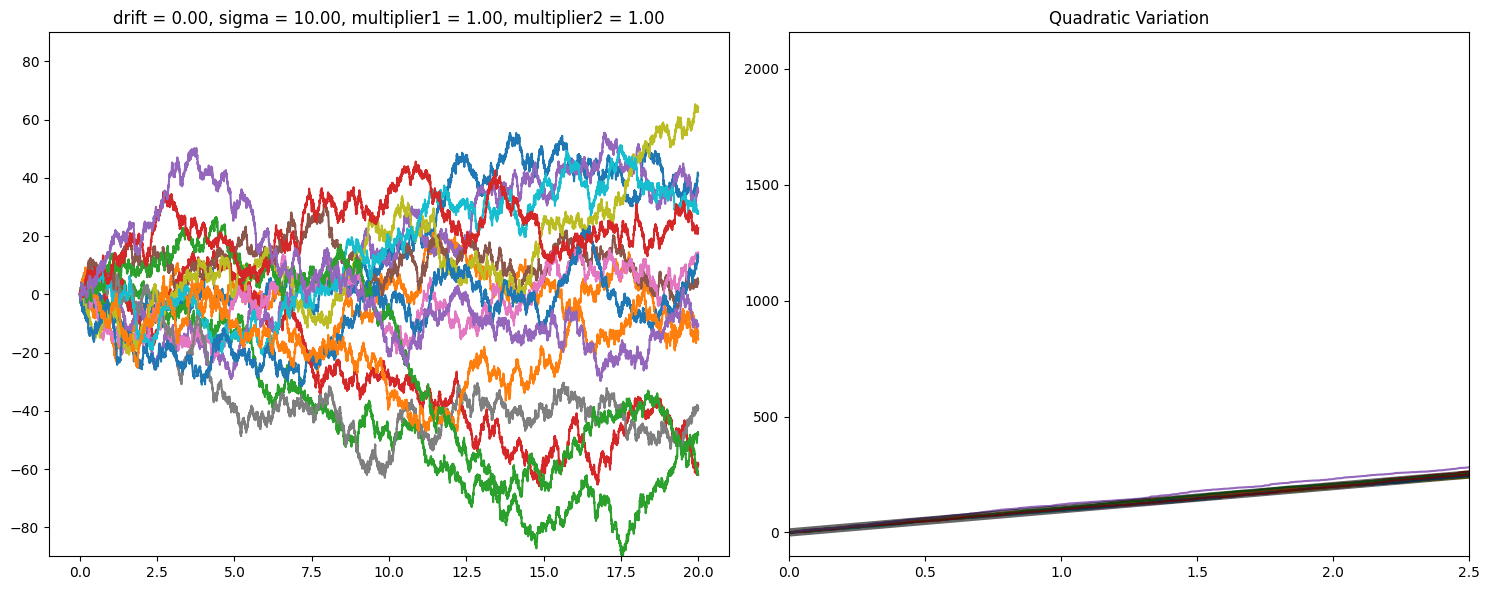

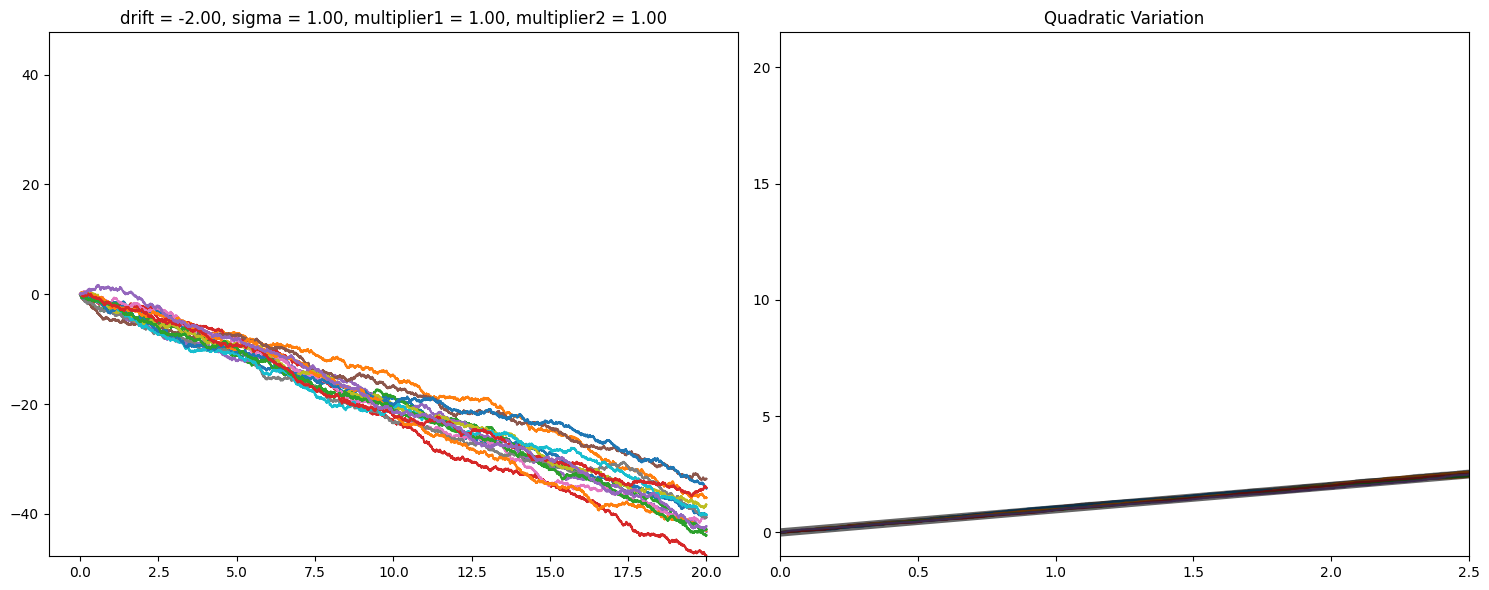

In [116]:
def model1(drift : float, sigma : float):
    dS = dX(drift, sigma)

model1(5, 1) #so the paths drift upward at average slope 5.
model1(0, 10) #huge randomness no trend
model1(-2, 1) #trends downward

# Model 2: The famous $dS = \mu S dt + \sigma S dX$

for fast im going to use the random walk of

$$S_t = S_0e^{(\mu + \sigma^2 / 2)t + \sigma (X_t - X_0)}$$

for which $W_0$ should NOT be 0

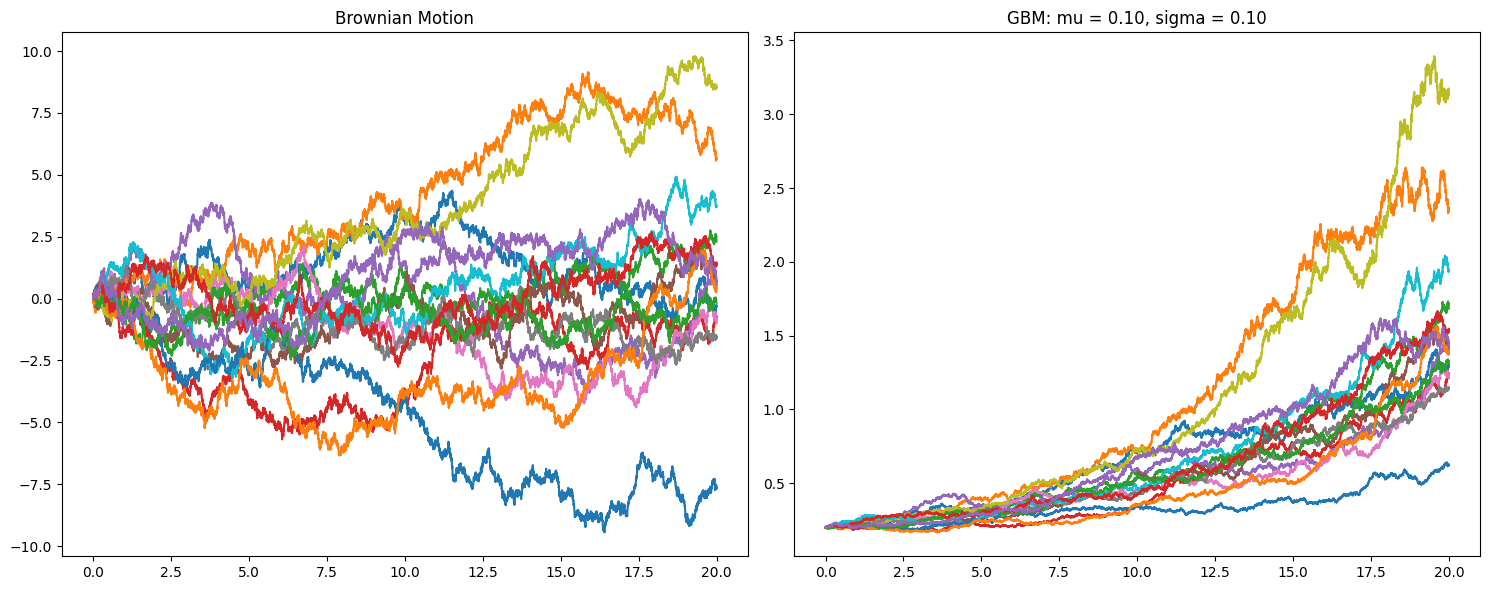

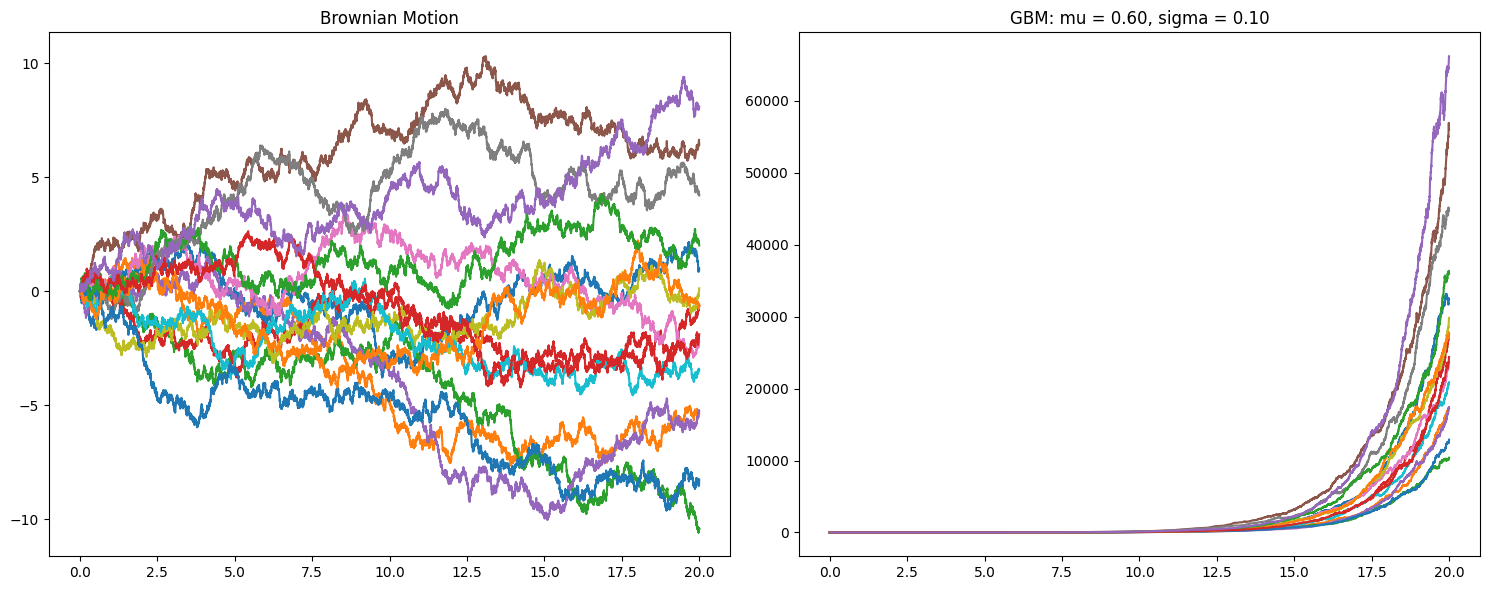

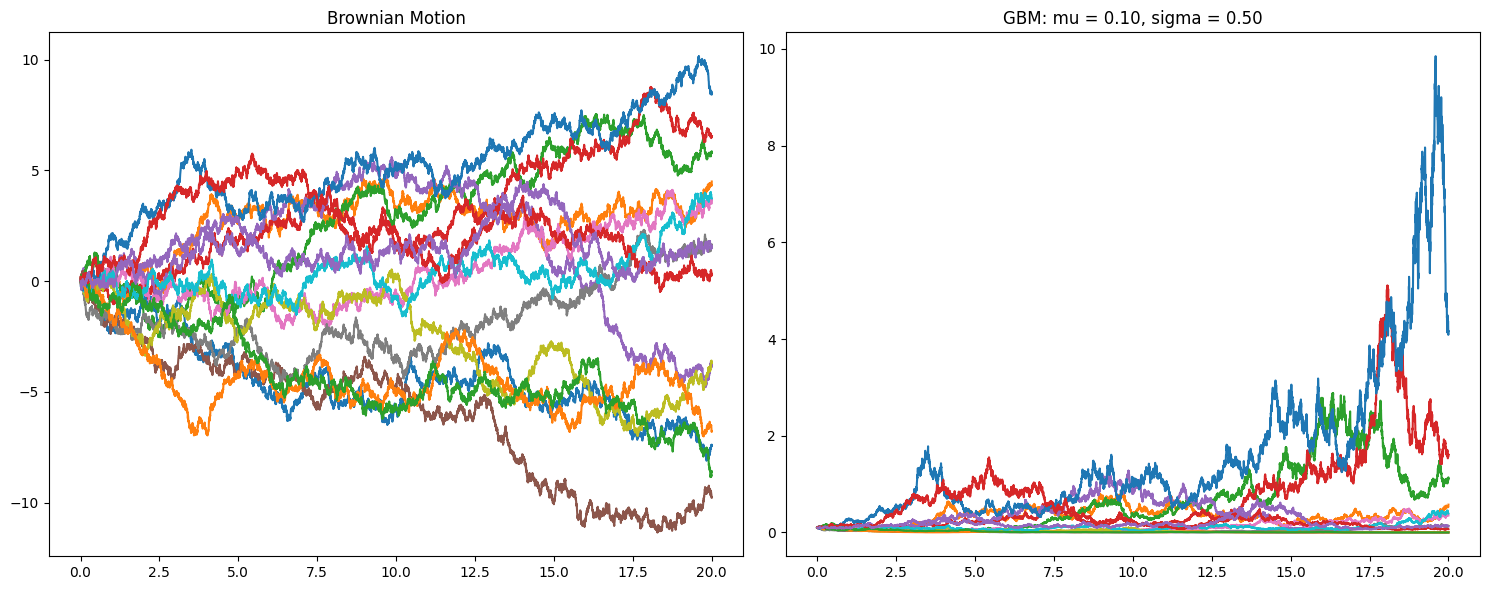

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def model2_gbm(mu : float, sigma : float, S0 : float = 1):

    n = 10000
    T = 20
    d = 15

    times = np.linspace(0., T, n)
    dt = times[1] - times[0]

    W0 = np.zeros(shape = (1, d))

    dW = np.random.normal(
        size = (n - 1, d),
        loc = 0,
        scale = np.sqrt(dt)
    )

    W_t = np.concatenate(
        (W0, np.cumsum(dW, axis = 0)),
        axis = 0
    )

    S_t = S0 * np.exp((mu - sigma ** 2 / 2) * times[:, None]+ sigma * W_t)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

    ax1.plot(times, W_t)
    ax1.set_title("Brownian Motion")

    ax2.plot(times, S_t)
    ax2.set_title(
        f"GBM: mu = {mu:.2f}, sigma = {sigma:.2f}"
    )

    plt.tight_layout()
    plt.show()
    
model2_gbm(0.1, 0.1, 0.2)
model2_gbm(0.6, 0.1, 0.2)
model2_gbm(0.1, 0.5, 0.1)


# The Vasiceik one: $dS = \kappa (\theta - r_t)dt + \sigma dX$

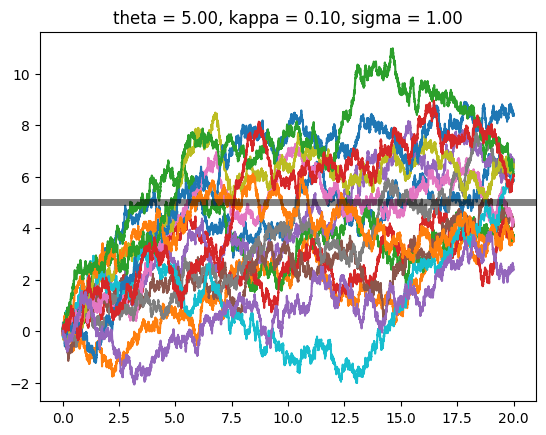

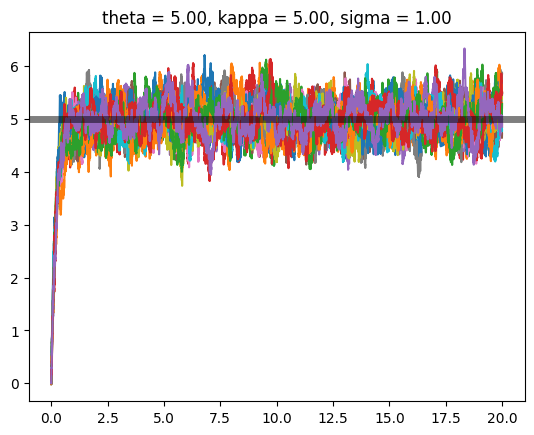

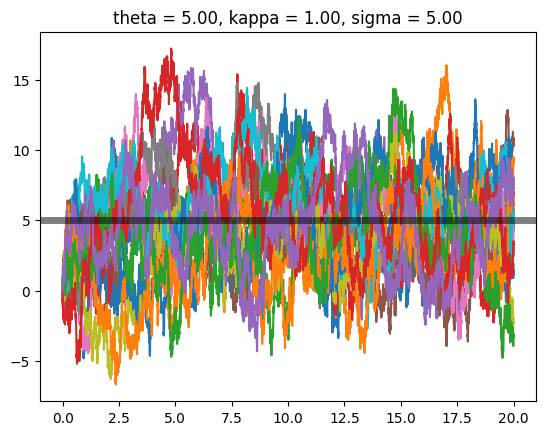

In [ ]:
def vasicek(theta : float,
            kappa : float,
            sigma : float,
            r0 : float):

    n = 10000
    T = 20
    d = 15

    times = np.linspace(0., T, n)
    dt = times[1] - times[0]

    r_t = np.zeros(shape = (n, d))
    r_t[0] = r0

    dW = np.random.normal(
        size = (n - 1, d),
        loc = 0,
        scale = np.sqrt(dt)
    )

    for i in range(n - 1):

        r_t[i + 1] = (r_t[i]+ kappa * (theta - r_t[i]) * dt+ sigma * dW[i])

    plt.figure()
    plt.plot(times, r_t)

    plt.axhline(
        y = theta,
        c = "black",
        linewidth = 5,
        alpha = 0.5
    )

    plt.title(
        f"theta = {theta:.2f}, "
        f"kappa = {kappa:.2f}, "
        f"sigma = {sigma:.2f}"
    )

    plt.show()
    
vasicek(theta = 5,kappa = 0.1, sigma = 1, r0 = 0)

vasicek(theta = 5,kappa = 5, sigma = 1, r0 = 0)

vasicek(theta = 5,kappa = 1,sigma = 5,r0 = 0)

# The CIR model: $dS = \kappa (\theta - S)dt + \sigma \sqrt(S) dX$

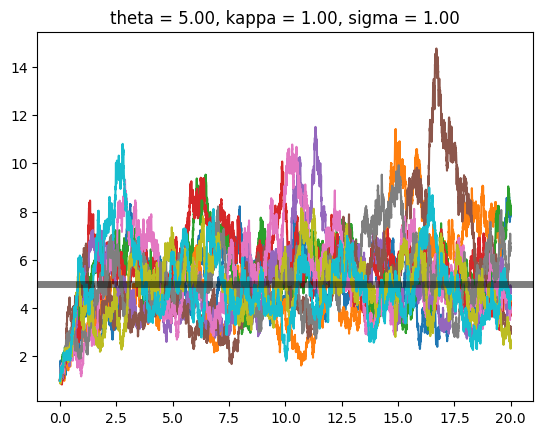

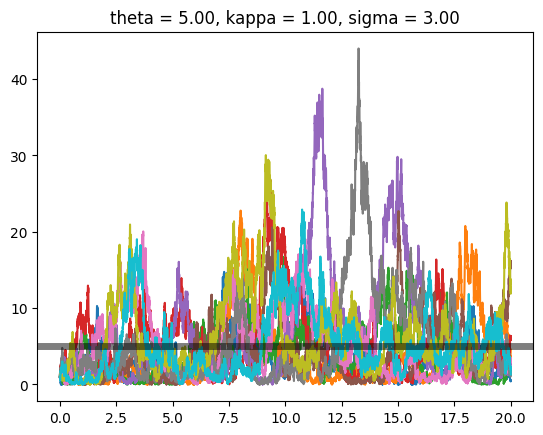

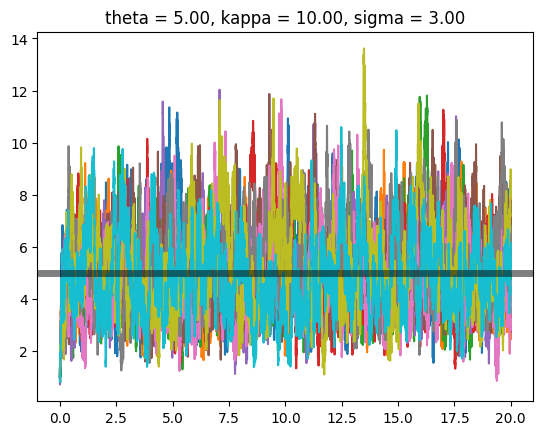

In [ ]:
def CIR(theta : float,
        kappa : float,
        sigma : float,
        S0 : float):

    n = 10000
    T = 20
    d = 10

    times = np.linspace(0., T, n)
    dt = times[1] - times[0]

    S_t = np.zeros(shape = (n, d))
    S_t[0] = S0

    dW = np.random.normal(
        size = (n - 1, d),
        loc = 0,
        scale = np.sqrt(dt)
    )

    for i in range(n - 1):

        S_t[i + 1] = (
            S_t[i]
            + kappa * (theta - S_t[i]) * dt
            + sigma * np.sqrt(np.maximum(S_t[i], 0)) * dW[i]
        )

        S_t[i + 1] = np.maximum(S_t[i + 1], 0)

    plt.figure()
    plt.plot(times, S_t)

    plt.axhline(
        y = theta,
        c = "black",
        linewidth = 5,
        alpha = 0.5
    )

    plt.title(
        f"theta = {theta:.2f}, "
        f"kappa = {kappa:.2f}, "
        f"sigma = {sigma:.2f}"
    )

    plt.show()
    
CIR(5, 1, 1, 1)
CIR(5, 1, 3, 1)
CIR(5, 10, 3, 1)


# Compare Vasciek and CIR:

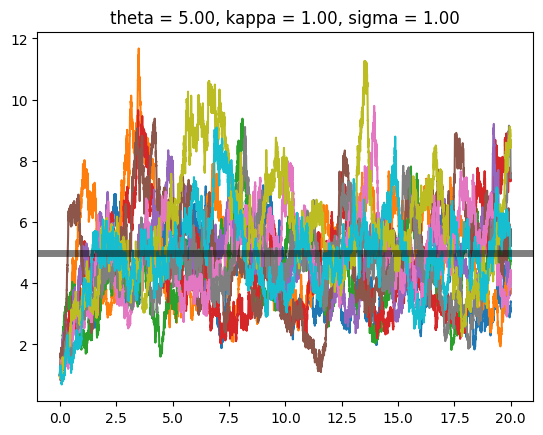

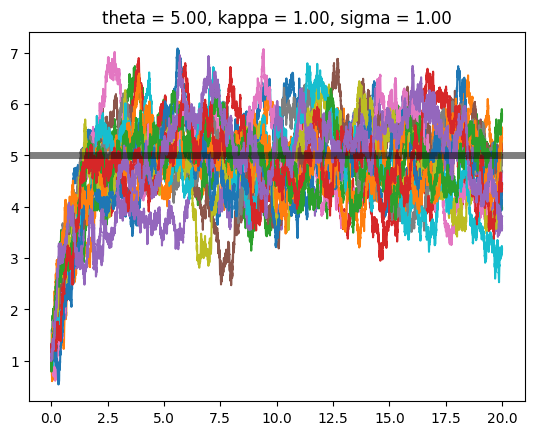

In [145]:
CIR(5,1,1,1)
vasicek(5,1,1,1)

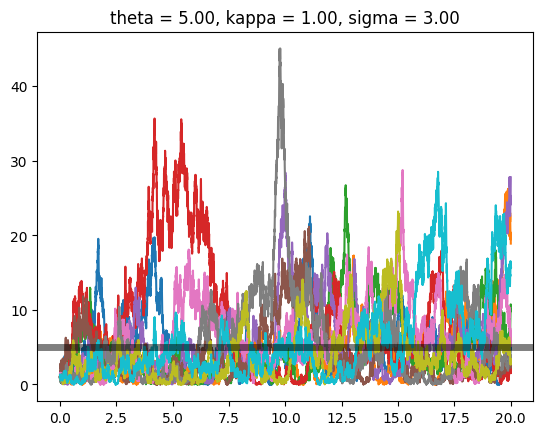

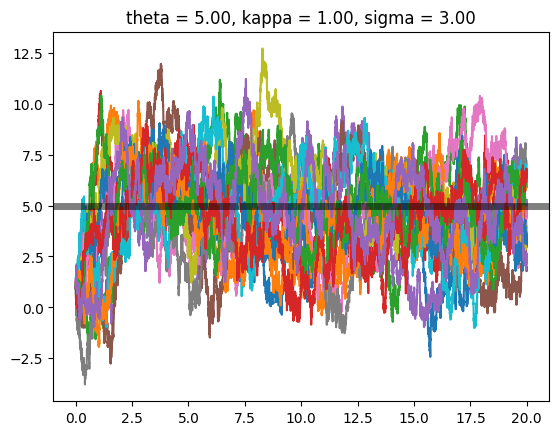

In [146]:
CIR(5,1,3,1)
vasicek(5,1,3,1)